<a href="https://colab.research.google.com/github/bibek193/FULLSTACK/blob/main/2509865_BibekKamat_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analysis of the World Happiness Report


Name - Bibek Kamat
Uni id - 2509865
**Course:** 5CS037 — Concepts and Technologies of AI

**Assignment:** Statistical Interpretation and Exploratory Data Analysis

**Dataset used:** `WHR20245CS037_a1bfcb8e-f3d5-49cf-9072-5f0f6923bbef_264243_.csv`

This notebook follows the assignment PDF and implements Problem 1, Problem 2, and Problem 3.


In [ ]:
# Imports and dataset load
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
%matplotlib inline

data_path = r"/content/WHR20245CS037_a1bfcb8e-f3d5-49cf-9072-5f0f6923bbef_264243_.csv"
print("Loading:", data_path)
df = pd.read_csv(data_path)
print("Loaded. Shape:", df.shape)
df.head(10)

Loading: /content/WHR20245CS037_a1bfcb8e-f3d5-49cf-9072-5f0f6923bbef_264243_.csv
Loaded. Shape: (143, 9)


,Country name,score,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
0,Finland,7.741,1.844,1.572,0.695,0.859,0.142,0.546,2.082
1,Denmark,7.583,1.908,1.520,0.699,0.823,0.204,0.548,1.881
2,Iceland,7.525,1.881,1.617,0.718,0.819,0.258,0.182,2.050
3,Sweden,7.344,1.878,1.501,0.724,0.838,0.221,0.524,1.658
4,Israel,7.341,1.803,1.513,0.740,0.641,0.153,0.193,2.298
5,Netherlands,7.319,1.901,1.462,0.706,0.725,0.247,0.372,1.906
6,Norway,7.302,1.952,1.517,0.704,0.835,0.224,0.484,1.586
7,Luxembourg,7.122,2.141,1.355,0.708,0.801,0.146,0.432,1.540
8,Switzerland,7.060,1.970,1.425,0.747,0.759,0.173,0.498,1.488
9,Australia,7.057,1.854,1.461,0.692,0.756,0.225,0.323,1.745


## Problem 1 — Getting Started with Data Exploration

In [ ]:
# 1.1 Display shape and dtypes
print('Rows, Columns:', df.shape)
print('\nColumns and dtypes:')
print(df.dtypes)

Rows, Columns: (143, 9)

Columns and dtypes:
Country name                     object
score                           float64
Log GDP per capita              float64
Social support                  float64
Healthy life expectancy         float64
Freedom to make life choices    float64
Generosity                      float64
Perceptions of corruption       float64
Dystopia + residual             float64
dtype: object


In [ ]:
# 1.2 Basic statistics for 'Score' column
score_mean = df['score'].mean()
score_median = df['score'].median()
score_std = df['score'].std()

print(f"Score mean: {score_mean:.4f}")
print(f"Score median: {score_median:.4f}")
print(f"Score std: {score_std:.4f}")

highest = df.loc[df['score'].idxmax()]
lowest = df.loc[df['score'].idxmin()]
print("\nHighest scoring country:", highest['Country name'], "Score:", highest['score'])
print("Lowest scoring country:", lowest['Country name'], "Score:", lowest['score'])

Score mean: 5.5276
Score median: 5.7850
Score std: 1.1707

Highest scoring country: Finland Score: 7.741
Lowest scoring country: Afghanistan Score: 1.721


In [ ]:
# 1.3 Missing values per column
missing = df.isnull().sum()
missing[missing>0] if missing.sum()>0 else print('No missing values found in the dataset.')
missing

,0
Country name,0
score,0
Log GDP per capita,3
Social support,3
Healthy life expectancy,3
Freedom to make life choices,3
Generosity,3
Perceptions of corruption,3
Dystopia + residual,3


In [ ]:
# 1.4 Filter countries with Score > 7.5 and sort by GDP per Capita (descending)
# find GDP column name
gdp_col = [c for c in df.columns if 'gdp' in c.lower()]
gdp_col = gdp_col[0] if gdp_col else 'GDP per Capita'
filtered = df[df['score'] > 7.5].sort_values(by=gdp_col, ascending=False)
filtered.head(10)

,Country name,score,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
1,Denmark,7.583,1.908,1.520,0.699,0.823,0.204,0.548,1.881
2,Iceland,7.525,1.881,1.617,0.718,0.819,0.258,0.182,2.050
0,Finland,7.741,1.844,1.572,0.695,0.859,0.142,0.546,2.082


In [ ]:
# 1.5 Add Happiness Category column
def happiness_category(score):
    if score < 4:
        return 'Low'
    elif score <= 6:
        return 'Medium'
    else:
        return 'High'

df['Happiness Category'] = df['score'].apply(happiness_category)
df[['Country name', 'score', 'Happiness Category']].head(10)

,Country name,score,Happiness Category
0,Finland,7.741,High
1,Denmark,7.583,High
2,Iceland,7.525,High
3,Sweden,7.344,High
4,Israel,7.341,High
5,Netherlands,7.319,High
6,Norway,7.302,High
7,Luxembourg,7.122,High
8,Switzerland,7.060,High
9,Australia,7.057,High


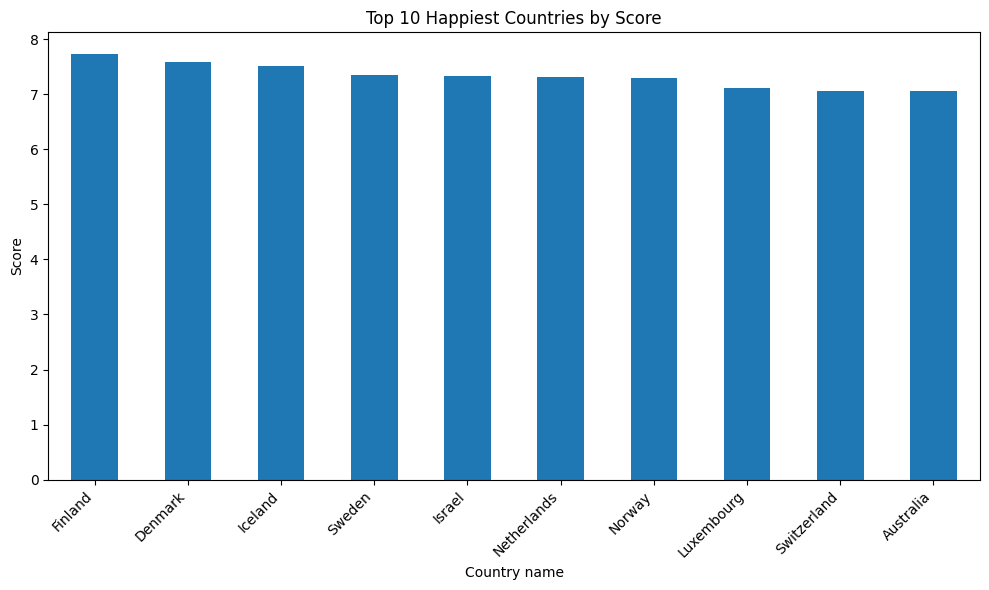

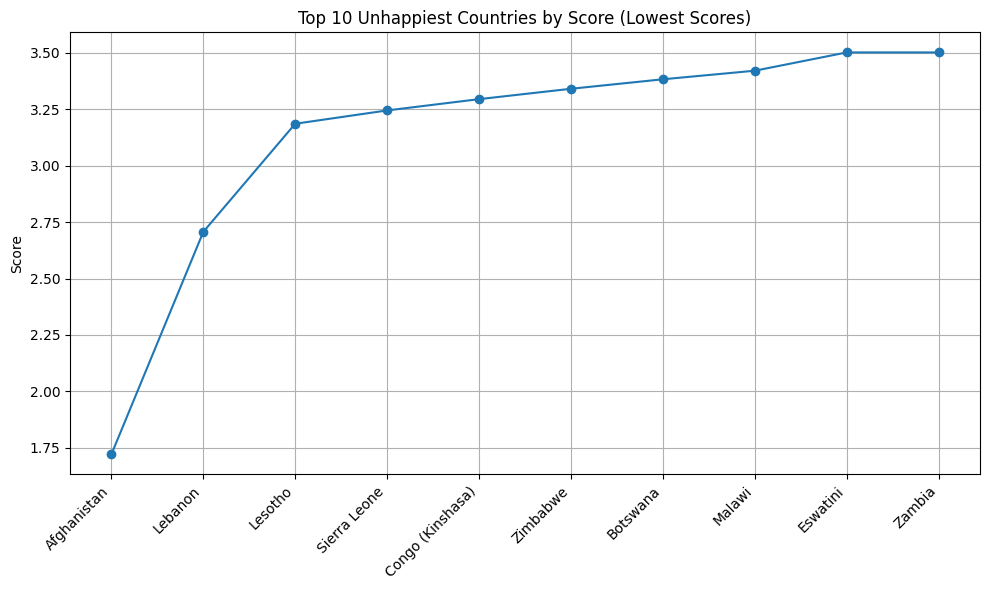

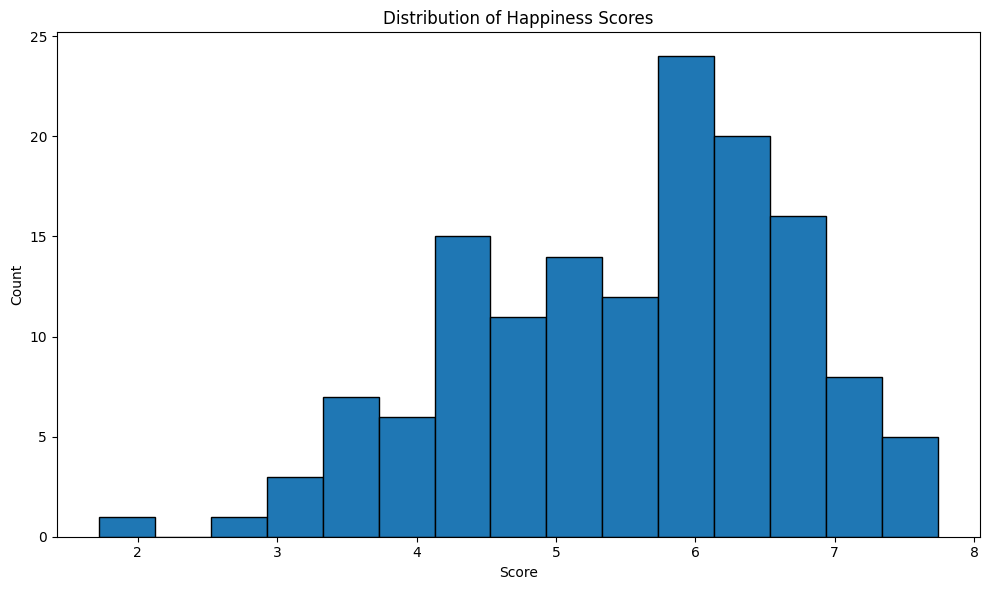

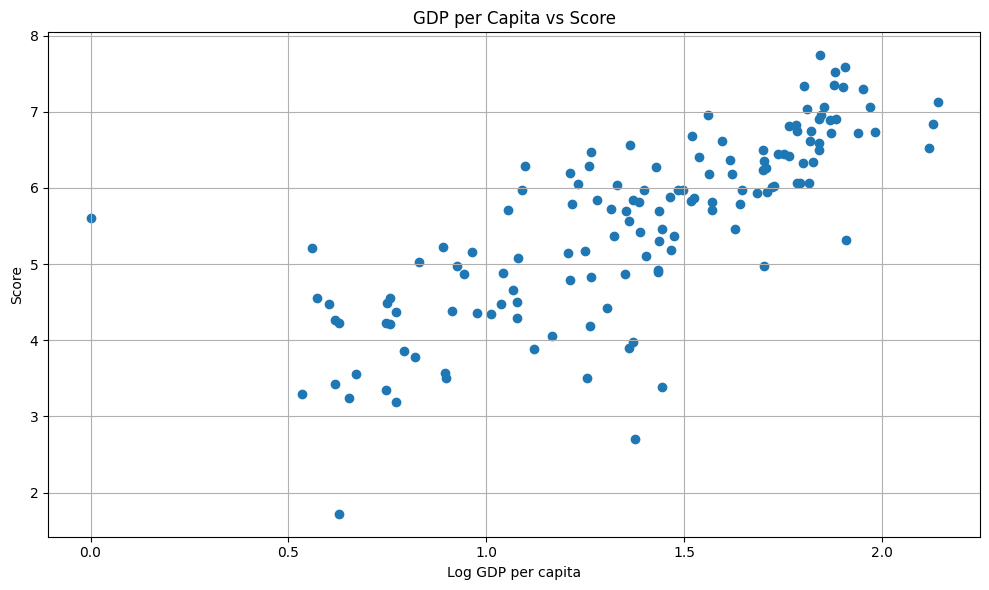

In [ ]:
# 1.6 Visualizations for Problem 1
plt.rcParams['figure.figsize'] = (10,6)

# Bar Plot: Top 10 happiest countries by Score
top10 = df.sort_values('score', ascending=False).head(10).set_index('Country name')
top10['score'].plot(kind='bar')
plt.title('Top 10 Happiest Countries by Score')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Line Plot: Top 10 unhappiest countries by Score (lowest scores)
bottom10 = df.sort_values('score', ascending=True).head(10).set_index('Country name')
plt.plot(bottom10.index, bottom10['score'], marker='o')
plt.title('Top 10 Unhappiest Countries by Score (Lowest Scores)')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()

# Histogram of Score
plt.hist(df['score'].dropna(), bins=15,edgecolor='black')
plt.title('Distribution of Happiness Scores')
plt.xlabel('Score')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Scatter between GDP per Capita and Score
plt.scatter(df[gdp_col], df['score'])
plt.title('GDP per Capita vs Score')
plt.xlabel(gdp_col)
plt.ylabel('Score')
plt.grid(True)
plt.tight_layout()
plt.show()

## Problem 2 — Advanced Data Exploration (South Asia)

In [ ]:
# 2.1 Define South Asian countries and create SouthAsia DataFrame and save to CSV
south_asian_countries = ["Afghanistan", "Bangladesh", "Bhutan", "India", "Maldives", "Nepal", "Pakistan", "Sri Lanka"]

south_df = df[df['Country name'].isin(south_asian_countries)].copy()
print('South Asia shape:', south_df.shape)
# south_df.to_csv('/mnt/data/World_Happiness_South_Asia.csv', index=False)
# 'Saved to /content/World_Happiness_South_Asia.csv'

South Asia shape: (6, 10)


In [ ]:
# 2.2 Composite Score calculation
# detect columns robustly
def find_col(df, keywords):
    for c in df.columns:
        for k in keywords:
            if k.lower() in c.lower():
                return c
    return None

gdp_col = find_col(df, ['gdp'])
social_col = find_col(df, ['social support', 'social'])
healthy_col = find_col(df, ['healthy life', 'life expectancy'])

print("Detected columns:", gdp_col, social_col, healthy_col)

Detected columns: Log GDP per capita Social support Healthy life expectancy


In [ ]:
# compute composite score using detected columns
south_df['Composite Score'] = (0.40 * south_df[gdp_col] + 0.30 * south_df[social_col] + 0.30 * south_df[healthy_col])
south_df = south_df.sort_values('Composite Score', ascending=False)
south_df[['Country name', gdp_col, social_col, healthy_col, 'Composite Score']]

,Country name,Log GDP per capita,Social support,Healthy life expectancy,Composite Score
127,Sri Lanka,1.361,1.179,0.586,1.0739
92,Nepal,0.965,0.990,0.443,0.8159
125,India,1.166,0.653,0.417,0.7874
107,Pakistan,1.069,0.600,0.321,0.7039
128,Bangladesh,1.122,0.249,0.513,0.6774
142,Afghanistan,0.628,0.000,0.242,0.3238


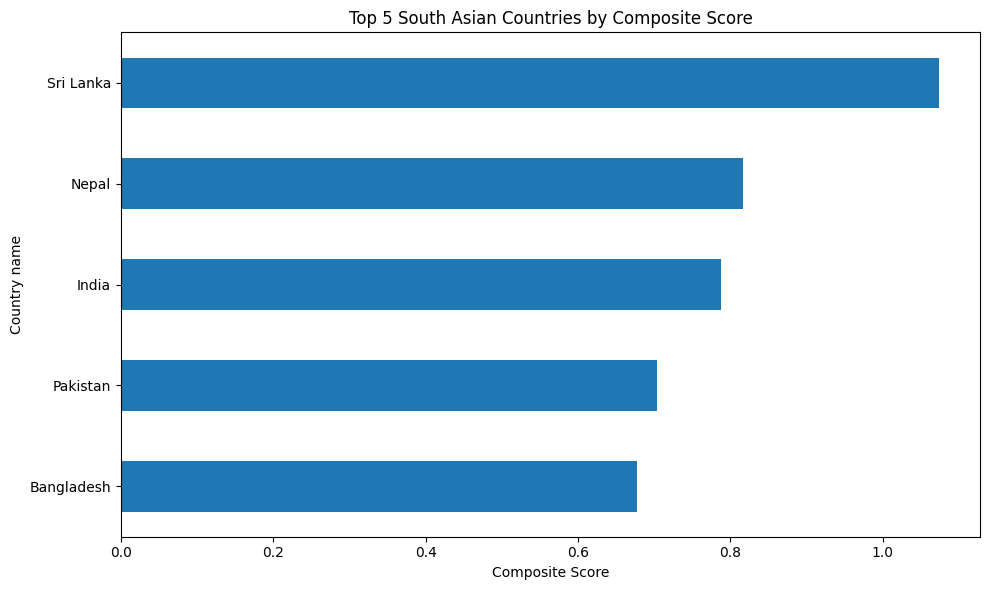

In [ ]:
# 2.3 Visualize top 5 South Asian countries by Composite Score (horizontal bar chart)
top5 = south_df.head(5).set_index('Country name')
top5['Composite Score'].plot(kind='barh')
plt.title('Top 5 South Asian Countries by Composite Score')
plt.xlabel('Composite Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# 2.4 Compare Composite Score ranking with original Score
comparison = south_df[['Country name','score','Composite Score']].copy().reset_index(drop=True)
comparison['Rank_by_Score'] = comparison['score'].rank(ascending=False, method='min')
comparison['Rank_by_Composite'] = comparison['Composite Score'].rank(ascending=False, method='min')
comparison = comparison.sort_values('Rank_by_Composite')
comparison

,Country name,score,Composite Score,Rank_by_Score,Rank_by_Composite
0,Sri Lanka,3.898,1.0739,4.0,1.0
1,Nepal,5.158,0.8159,1.0,2.0
2,India,4.054,0.7874,3.0,3.0
3,Pakistan,4.657,0.7039,2.0,4.0
4,Bangladesh,3.886,0.6774,5.0,5.0
5,Afghanistan,1.721,0.3238,6.0,6.0


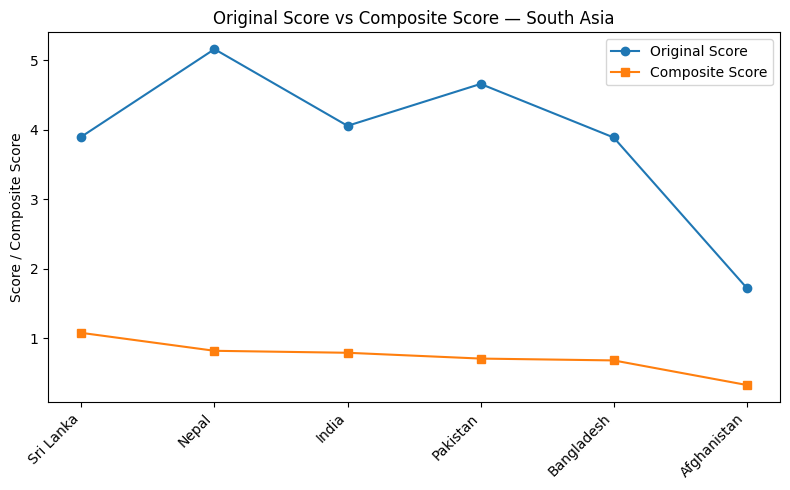

In [ ]:
# Visualize differences between Score and Composite Score
plt.figure(figsize=(8,5))
x = np.arange(len(comparison))
plt.plot(x, comparison['score'], marker='o', label='Original Score')
plt.plot(x, comparison['Composite Score'], marker='s', label='Composite Score')
plt.xticks(x, comparison['Country name'], rotation=45, ha='right')
plt.ylabel('Score / Composite Score')
plt.title('Original Score vs Composite Score — South Asia')
plt.legend()
plt.tight_layout()
plt.show()

Score outliers:


,Country name,score
142,Afghanistan,1.721



GDP outliers:


,Country name,Log GDP per capita
142,Afghanistan,0.628


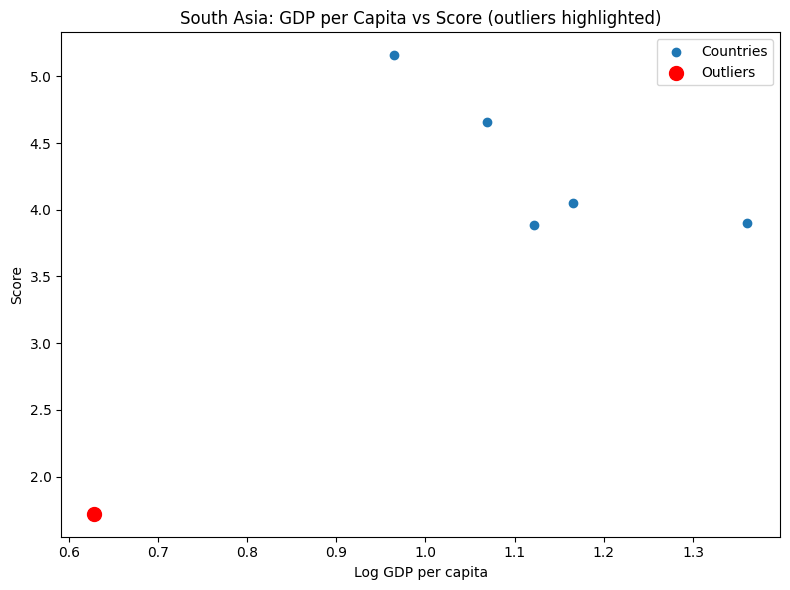

In [ ]:
# 2.5 Outlier Detection in South Asia using 1.5*IQR rule
def detect_outliers_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr
    return lower, upper

score_lower, score_upper = detect_outliers_iqr(south_df['score'])
gdp_lower, gdp_upper = detect_outliers_iqr(south_df[gdp_col])

score_outliers = south_df[(south_df['score'] < score_lower) | (south_df['score'] > score_upper)]
gdp_outliers = south_df[(south_df[gdp_col] < gdp_lower) | (south_df[gdp_col] > gdp_upper)]

print('Score outliers:'); display(score_outliers[['Country name','score']])
print('\nGDP outliers:'); display(gdp_outliers[['Country name', gdp_col]])

# Scatter plot with outliers highlighted
plt.figure(figsize=(8,6))
plt.scatter(south_df[gdp_col], south_df['score'], label='Countries')
if not score_outliers.empty or not gdp_outliers.empty:
    outlier_idx = pd.Index.union(score_outliers.index, gdp_outliers.index)
    plt.scatter(south_df.loc[outlier_idx, gdp_col], south_df.loc[outlier_idx, 'score'], color='red', label='Outliers', s=100)
plt.xlabel(gdp_col)
plt.ylabel('Score')
plt.title('South Asia: GDP per Capita vs Score (outliers highlighted)')
plt.legend()
plt.tight_layout()
plt.show()

Detected columns: Freedom to make life choices Generosity
Pearson correlation Score vs Freedom to make life choices: 0.8005
Pearson correlation Score vs Generosity: 0.8745


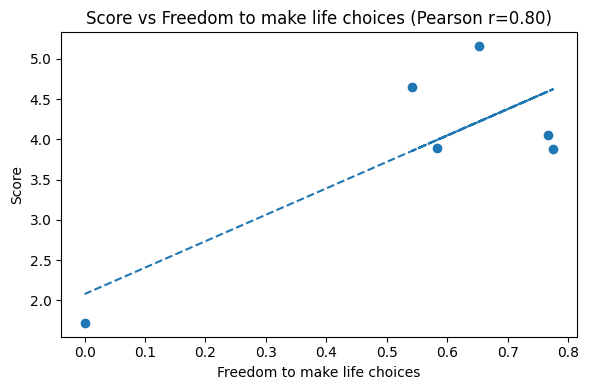

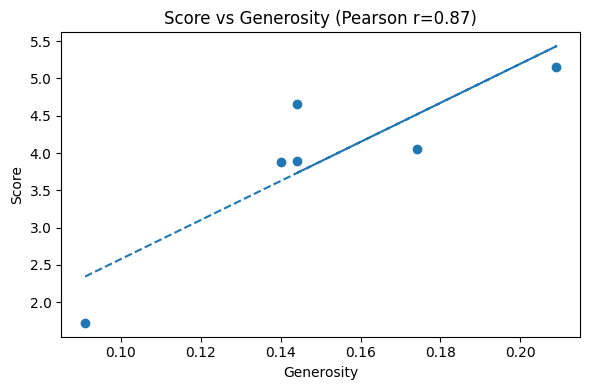

In [ ]:
# 2.6 Correlation analysis for Freedom and Generosity in South Asia
def find_col_contains(df, token_list):
    for c in df.columns:
        low = c.lower()
        for t in token_list:
            if t.lower() in low:
                return c
    return None

freedom_col = find_col_contains(south_df, ['freedom'])
generosity_col = find_col_contains(south_df, ['generosity'])

print('Detected columns:', freedom_col, generosity_col)
corr_freedom = south_df['score'].corr(south_df[freedom_col])
corr_generosity = south_df['score'].corr(south_df[generosity_col])
print(f'Pearson correlation Score vs {freedom_col}: {corr_freedom:.4f}')
print(f'Pearson correlation Score vs {generosity_col}: {corr_generosity:.4f}')

for col in [freedom_col, generosity_col]:
    plt.figure(figsize=(6,4))
    plt.scatter(south_df[col], south_df['score'])
    m, b = np.polyfit(south_df[col], south_df['score'], 1)
    plt.plot(south_df[col], m*south_df[col] + b, linestyle='--')
    plt.xlabel(col)
    plt.ylabel('Score')
    plt.title(f'Score vs {col} (Pearson r={south_df[col].corr(south_df["score"]):.2f})')
    plt.tight_layout()
    plt.show()

Top 3 largest positive gaps:


,Country name,GDP-Score Gap
142,Afghanistan,-1.093
127,Sri Lanka,-2.537
128,Bangladesh,-2.764



Top 3 largest negative gaps:


,Country name,GDP-Score Gap
92,Nepal,-4.193
107,Pakistan,-3.588
125,India,-2.888


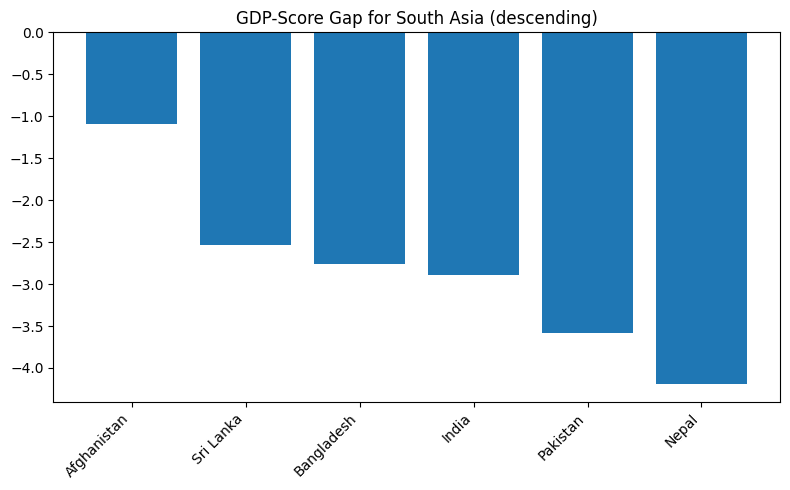

In [ ]:
# 2.7 Gap Analysis: GDP-Score Gap
south_df['GDP-Score Gap'] = south_df[gdp_col] - south_df['score']
gap_sorted_desc = south_df.sort_values('GDP-Score Gap', ascending=False)
gap_sorted_asc = south_df.sort_values('GDP-Score Gap', ascending=True)
top3_positive = gap_sorted_desc.head(3)
top3_negative = gap_sorted_asc.head(3)

print('Top 3 largest positive gaps:'); display(top3_positive[['Country name','GDP-Score Gap']])
print('\nTop 3 largest negative gaps:'); display(top3_negative[['Country name','GDP-Score Gap']])

plt.figure(figsize=(8,5))
plt.bar(gap_sorted_desc['Country name'], gap_sorted_desc['GDP-Score Gap'])
plt.title('GDP-Score Gap for South Asia (descending)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# 3.1 Prepare Middle East DataFrame and save
middle_east_countries = [ "Bahrain", "Iran", "Iraq", "Israel", "Jordan", "Kuwait", "Lebanon", "Oman", "Palestine", "Qatar", "Saudi Arabia", "Syria", "United Arab Emirates", "Yemen" ]

me_df = df[df['Country name'].isin(middle_east_countries)].copy()
print('Middle East shape:', me_df.shape)
# me_df.to_csv('/mnt/data/World_Happiness_Middle_East.csv', index=False)
# 'Saved Middle East CSV to /mnt/data/World_Happiness_Middle_East.csv'

Middle East shape: (10, 10)


In [ ]:
# Re-define column names to ensure they are in scope
gdp_col = find_col(df, ['gdp'])
social_col = find_col(df, ['social support', 'social'])
healthy_col = find_col(df, ['healthy life', 'life expectancy'])
print("Confirmed detected columns:", gdp_col, social_col, healthy_col)

Confirmed detected columns: Log GDP per capita Social support Healthy life expectancy


In [ ]:
# Re-define column names to ensure they are in scope
def find_col(df, keywords):
    for c in df.columns:
        for k in keywords:
            if k.lower() in c.lower():
                return c
    return None

gdp_col = find_col(df, ['gdp'])
social_col = find_col(df, ['social support', 'social'])
healthy_col = find_col(df, ['healthy life', 'life expectancy'])
print("Confirmed detected columns:", gdp_col, social_col, healthy_col)

Confirmed detected columns: Log GDP per capita Social support Healthy life expectancy


In [ ]:
# 3.2 Descriptive statistics: mean and std of Score for both regions
sa_mean = south_df['score'].mean()
sa_std = south_df['score'].std()
me_mean = me_df['score'].mean()
me_std = me_df['score'].std()

print('South Asia — mean:', sa_mean, 'std:', sa_std)
print('Middle East — mean:', me_mean, 'std:', me_std)

South Asia — mean: 3.895666666666667 std: 1.1770690152521501
Middle East — mean: 5.412100000000001 std: 1.5662011684327144


In [ ]:
# 3.3 Top 3 and bottom 3 countries in each region by Score
def top_bottom(df, n=3):
    top = df.sort_values('score', ascending=False).head(n)[['Country name','score']]
    bottom = df.sort_values('score', ascending=True).head(n)[['Country name','score']]
    return top, bottom

sa_top3, sa_bottom3 = top_bottom(south_df, 3)
me_top3, me_bottom3 = top_bottom(me_df, 3)

print('South Asia Top 3:'); display(sa_top3)
print('South Asia Bottom 3:'); display(sa_bottom3)
print('\nMiddle East Top 3:'); display(me_top3)
print('Middle East Bottom 3:'); display(me_bottom3)

South Asia Top 3:


,Country name,score
92,Nepal,5.158
107,Pakistan,4.657
125,India,4.054


South Asia Bottom 3:


,Country name,score
142,Afghanistan,1.721
128,Bangladesh,3.886
127,Sri Lanka,3.898



Middle East Top 3:


,Country name,score
4,Israel,7.341
12,Kuwait,6.951
21,United Arab Emirates,6.733


Middle East Bottom 3:


,Country name,score
141,Lebanon,2.707
132,Yemen,3.561
124,Jordan,4.186


In [ ]:
# 3.4 Compare key metrics between regions (mean)
metrics = [gdp_col, social_col, healthy_col]
sa_metrics_mean = south_df[metrics].mean()
me_metrics_mean = me_df[metrics].mean()
comp_df = pd.DataFrame({'South Asia': sa_metrics_mean, 'Middle East': me_metrics_mean})
comp_df

,South Asia,Middle East
Log GDP per capita,1.051833,1.496333
Social support,0.611833,1.152778
Healthy life expectancy,0.420333,0.554111


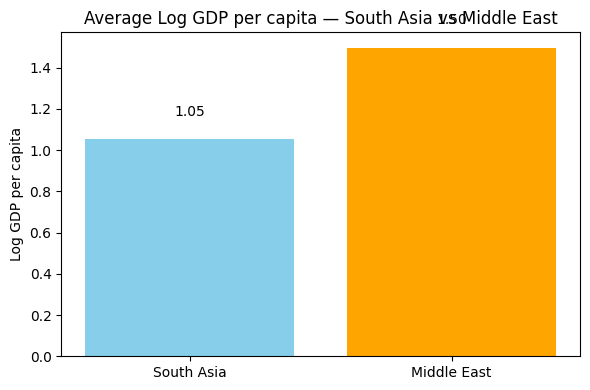

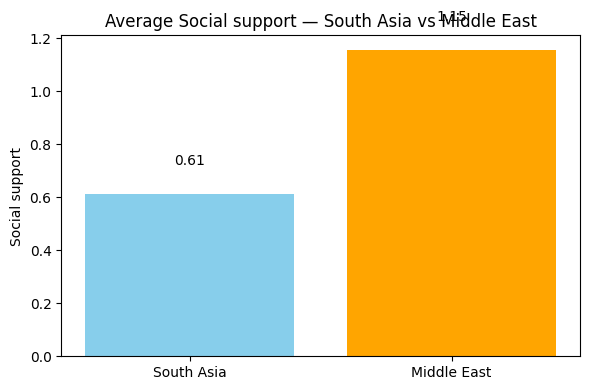

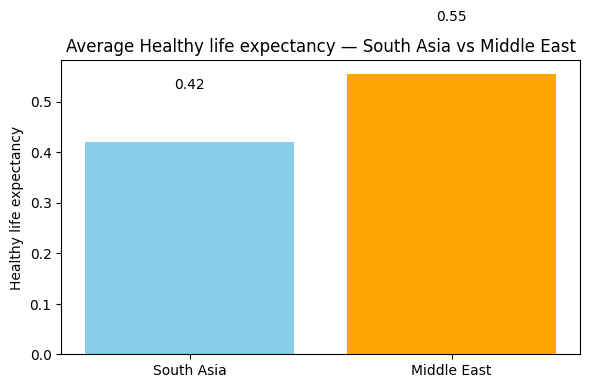

In [ ]:
# Grouped bar charts for each metric
for metric in metrics:
    plt.figure(figsize=(6,4))

    # Compute mean values
    values = [south_df[metric].mean(), me_df[metric].mean()]

    # Plot bars with different colors
    bars = plt.bar(['South Asia','Middle East'], values, color=['skyblue', 'orange'])

    # Add title and labels
    plt.title(f'Average {metric} — South Asia vs Middle East')
    plt.ylabel(metric)

    # Add data labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.1, f'{height:.2f}', ha='center', va='bottom')

    # Adjust layout and show plot
    plt.tight_layout()
    plt.show()


In [ ]:
# 3.5 Happiness disparity: range and coefficient of variation for Score
def coef_variation(series):
    return series.std() / series.mean() if series.mean() != 0 else np.nan

sa_range = south_df['score'].max() - south_df['score'].min()
me_range = me_df['score'].max() - me_df['score'].min()
sa_cv = coef_variation(south_df['score'])
me_cv = coef_variation(me_df['score'])

print('South Asia — Range:', sa_range, 'CV:', sa_cv)
print('Middle East — Range:', me_range, 'CV:', me_cv)

South Asia — Range: 3.4370000000000003 CV: 0.30214828833374263
Middle East — Range: 4.634 CV: 0.28938880812119405



Region: South Asia
Score vs Freedom to make life choices pearson r = 0.8005185224163315
Score vs Generosity pearson r = 0.874512371253192


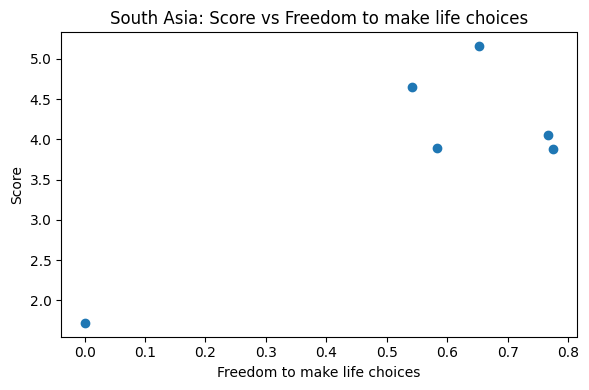

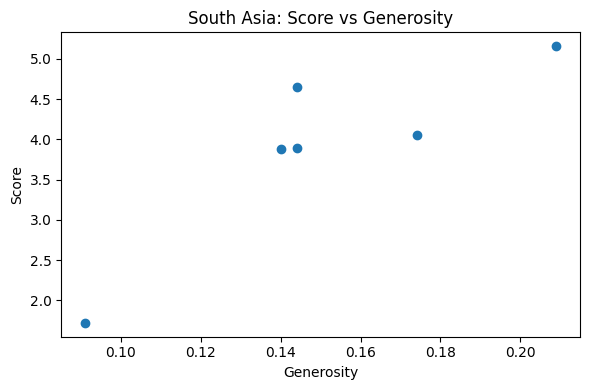


Region: Middle East
Score vs Freedom to make life choices pearson r = 0.8632202433827544
Score vs Generosity pearson r = 0.6275236536964182


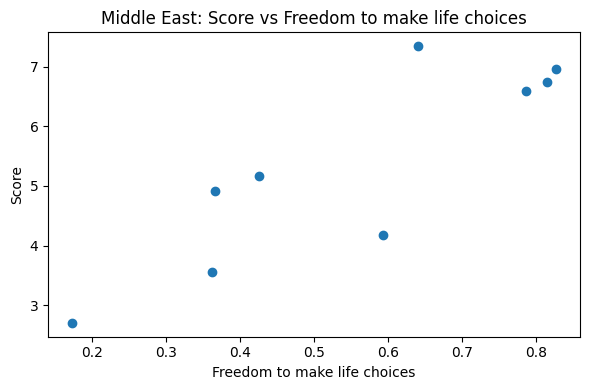

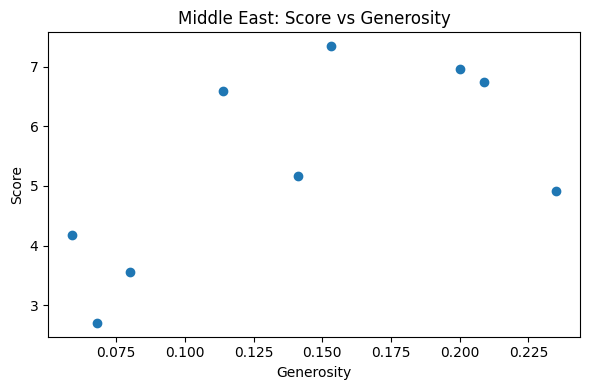

In [ ]:
# 3.6 Correlation analysis: Score vs Freedom and Generosity for each region (with scatter plots)
for region_name, region_df in [('South Asia', south_df), ('Middle East', me_df)]:
    fcol = find_col_contains(region_df, ['freedom'])
    gcol = find_col_contains(region_df, ['generosity'])
    print('\nRegion:', region_name)
    print('Score vs', fcol, 'pearson r =', region_df['score'].corr(region_df[fcol]))
    print('Score vs', gcol, 'pearson r =', region_df['score'].corr(region_df[gcol]))
    plt.figure(figsize=(6,4))
    plt.scatter(region_df[fcol], region_df['score'])
    plt.title(f'{region_name}: Score vs {fcol}')
    plt.xlabel(fcol); plt.ylabel('Score'); plt.tight_layout(); plt.show()
    plt.figure(figsize=(6,4))
    plt.scatter(region_df[gcol], region_df['score'])
    plt.title(f'{region_name}: Score vs {gcol}')
    plt.xlabel(gcol); plt.ylabel('Score'); plt.tight_layout(); plt.show()

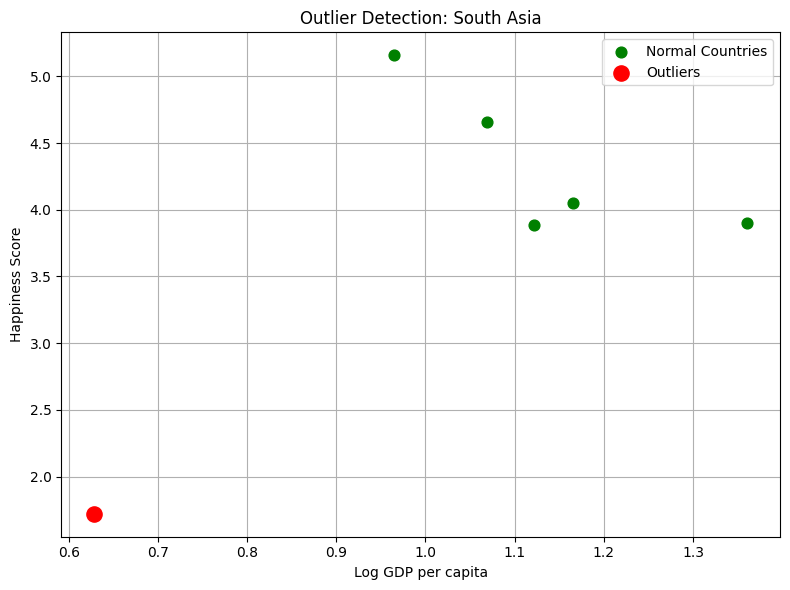

South Asia Outliers:


,Country name,score,Log GDP per capita
142,Afghanistan,1.721,0.628


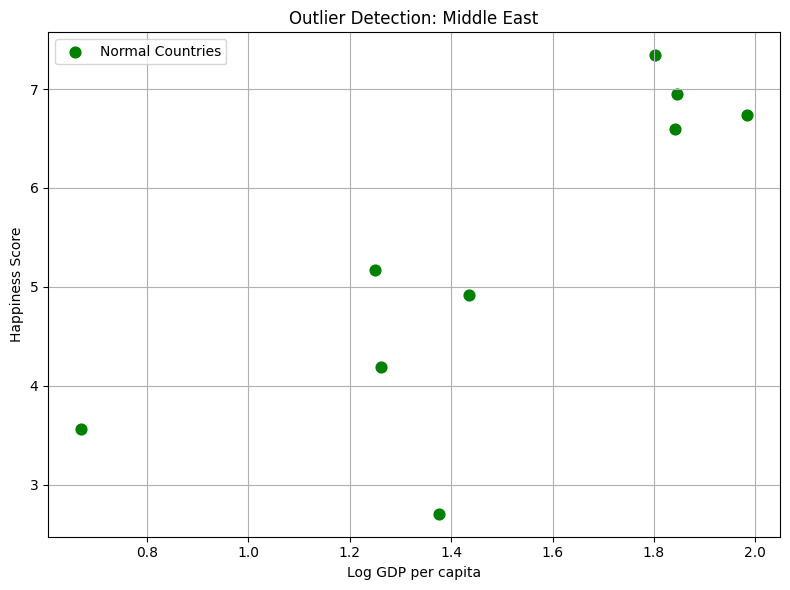

Middle East Outliers:


,Country name,score,Log GDP per capita


In [ ]:
# 3.7 Outlier Plot for Both South Asia and Middle East

def plot_outliers(region_df, region_name):
    # Calculate bounds
    s_low, s_up = detect_outliers_iqr(region_df["score"])
    g_low, g_up = detect_outliers_iqr(region_df[gdp_col])

    # Detect outliers
    outliers = region_df[
        (region_df["score"] < s_low) | (region_df["score"] > s_up) |
        (region_df[gdp_col] < g_low) | (region_df[gdp_col] > g_up)
    ]

    # Scatter plot
    plt.figure(figsize=(8,6))

    # Normal points
    plt.scatter(region_df[gdp_col], region_df["score"],
                label="Normal Countries", s=60, color='green')

    # Outliers
    if not outliers.empty:
        plt.scatter(outliers[gdp_col], outliers["score"],
                    color="red", s=120, label="Outliers")

    plt.title(f"Outlier Detection: {region_name}")
    plt.xlabel(gdp_col)
    plt.ylabel("Happiness Score")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return outliers


# Plot for South Asia
south_outliers = plot_outliers(south_df, "South Asia")
print("South Asia Outliers:")
display(south_outliers[["Country name", "score", gdp_col]])

# Plot for Middle East
me_outliers = plot_outliers(me_df, "Middle East")
print("Middle East Outliers:")
display(me_outliers[["Country name", "score", gdp_col]])

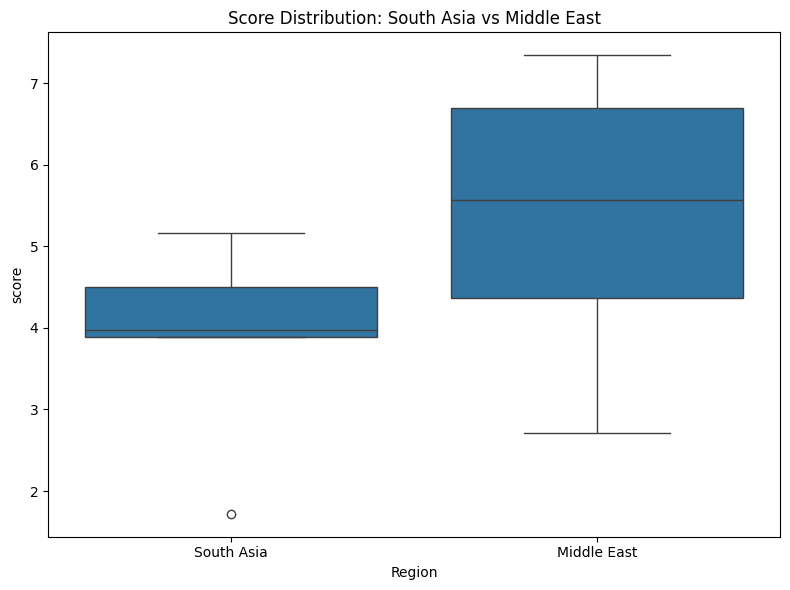

In [ ]:
# 3.8 Boxplots comparing Score distribution between South Asia and Middle East
combined = pd.concat([south_df.assign(Region='South Asia'), me_df.assign(Region='Middle East')], ignore_index=True)
plt.figure(figsize=(8,6))
sns.boxplot(x='Region', y='score', data=combined)
plt.title('Score Distribution: South Asia vs Middle East')
plt.tight_layout()
plt.show()

## Conclusion

The notebook implements the assignment steps. Saved outputs:

- `/mnt/data/World_Happiness_South_Asia.csv`
- `/mnt/data/World_Happiness_Middle_East.csv`

Notebook saved to `/mnt/data/WHR_Assignment_5CS037_Assignment1.ipynb`